# Hands on session on LCNU decomposition and circuit synthesis

The notebook does four things:

1. Setup the linear system for heat equation
2. Construct the LCNU decomposition for it
3. Build the unitary for an LCNU term
4. Use the constructed unitary to run Hadamard tests

References: 
1. Gnanasekaran and Surana, Efficient quantum access model for sparse structured matrices using linear combination of “things”, Phys. Rev. A 113, 022437 (2026), arXiv:2507.03714
2. Gnanasekaran and Surana, Efficient variational quantum linear solver for structured sparse matrices, IEEE QCE 2024

In [1]:
import sys
sys.path.insert(0, ".")

from itertools import product
import numpy as np
import matplotlib.pyplot as plt
import qiskit
from qiskit import QuantumCircuit

from src import autoextract, report
from src.sigma import dense, pretty, sigma_matrix, single_entry_term
from src.pdes import heat_system, nnz
from src.decompose import lcnu_heat, pauli_lcu
from src.circuits import circuit_matrix, explain_term, sigma_term_circuit
from src.hadamard import (hadamard_test_pair, hadamard_test_single, inner_pair,
                          inner_single, prep_from_vector, random_state_prep, state_of)
from src.vqls import (ansatz, beta_exact, beta_from_tests, cost_global_exact,
                      cost_global_from_tests, cost_local_exact,
                      cost_local_from_tests, n_params)

np.set_printoptions(precision=3, suppress=True, linewidth=140)
print("qiskit", qiskit.__version__, " numpy", np.__version__)

qiskit 1.4.6  numpy 2.5.2


## 1. The Sigma basis

The Sigma basis adds four non-unitary operators to the identity:

$$\mathbb{S} = \{\mathbf{I},\, \sigma_+,\, \sigma_-,\, \sigma_+\sigma_-,\, \sigma_-\sigma_+\}, \qquad
\sigma_+ = |0\rangle\langle 1|, \quad \sigma_- = |1\rangle\langle 0|, \quad
\sigma_+\sigma_- = |0\rangle\langle 0|, \quad \sigma_-\sigma_+ = |1\rangle\langle 1|.$$

One LCNU term is a tensor product $\mathbf{A}_l = \sigma_0 \otimes \cdots \otimes \sigma_{n-1}$.

A string of $n$ letters encodes one term. Each letter fixes the row bit and the column bit of that factor:

| letter | operator | (row bit, column bit) |
|---|---|---|
| `P` | $\sigma_+\sigma_-$ | (0, 0) |
| `+` | $\sigma_+$ | (0, 1) |
| `-` | $\sigma_-$ | (1, 0) |
| `M` | $\sigma_-\sigma_+$ | (1, 1) |
| `I` | $\mathbf{I}$ | (0, 0) and (1, 1) |


**Qubit order.** Position $p$ of the term goes on wire $q_{n-1-p}$ (little endian notation)

## 2. The heat equation as one linear system

A rod conducts heat. A constant flux $q$ enters at $x=0$. The end at $x=l$ is insulated.

$$\frac{\partial u}{\partial t} = \alpha \frac{\partial^2 u}{\partial x^2}, \qquad
-k\left.\frac{\partial u}{\partial x}\right|_{x=0} = q, \qquad
-k\left.\frac{\partial u}{\partial x}\right|_{x=l} = 0.$$

Use $n_x$ points in space and $n_t$ levels in time. Use central differences and backward Euler. One step becomes

$$\left(\mathbf{I} - c\,\mathbf{A}'\right)\mathbf{u}_{j} = \mathbf{u}_{j-1} + \frac{q\,\Delta t}{k\,\Delta x}\mathbf{e}_1,
\qquad c = \frac{\alpha\,\Delta t}{(\Delta x)^2}.$$

$\mathbf{A}'$ is the Laplacian with a zero-flux stencil at both ends. Its two corner entries are $-1$, not $-2$.

Now stack every time level into one vector. The result is a single system $\mathbf{A}\mathbf{u} = \mathbf{b}$:

$$\mathbf{A} = \underbrace{\begin{pmatrix}\mathbf{I} & & \\ -\mathbf{I} & \ddots & \\ & -\mathbf{I} & \mathbf{I}\end{pmatrix}}_{\mathbf{A}_1}
\;-\; c \underbrace{\begin{pmatrix}\mathbf{0} &  & \\ & \ddots & \\ & & \mathbf{A}'\end{pmatrix}}_{\mathbf{A}_2}.$$

Set $n_x = 2^s$ and $n_t = 2^t$. Then $\mathbf{A}$ acts on $n = s + t$ qubits, and the time index takes the high bits.

A is 16x16 on 4 qubits,   c = 0.0900,   nnz(A) = 46


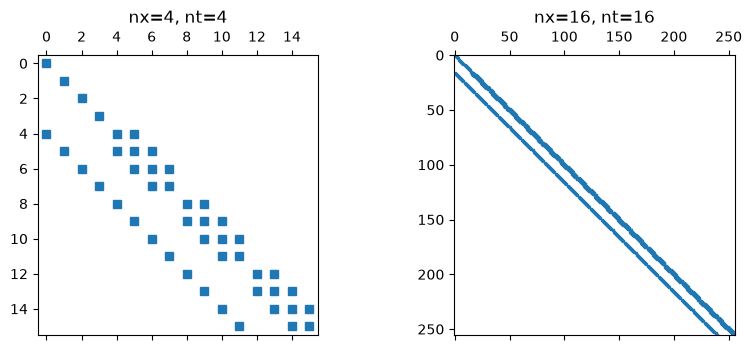

In [2]:
A, b, meta = heat_system(nx=4, nt=4)
print("A is %dx%d on %d qubits,   c = %.4f,   nnz(A) = %d"
      % (A.shape[0], A.shape[1], int(round(np.log2(A.shape[0]))), meta["c"], nnz(A)))

# Kept at its original look, so it opts out of the slide font settings.
with plt.rc_context(report.ORIGINAL_STYLE):
    fig, ax = plt.subplots(1, 2, figsize=(8.5, 3.6))
    ax[0].spy(A, markersize=6)
    ax[0].set_title("nx=4, nt=4")
    ax[1].spy(heat_system(16, 16, dt=0.02)[0], markersize=2)
    ax[1].set_title("nx=16, nt=16")
    plt.tight_layout()
    report.save_fig("heat_spy", tight=True)
    plt.show()

## 3. The hand-compute decomposition

Split a matrix on its most significant qubit:

$$\mathbf{B} = \begin{pmatrix}\mathbf{B}_{00} & \mathbf{B}_{01}\\ \mathbf{B}_{10} & \mathbf{B}_{11}\end{pmatrix}
= \sigma_+\sigma_-\otimes\mathbf{B}_{00} + \sigma_+\otimes\mathbf{B}_{01}
+ \sigma_-\otimes\mathbf{B}_{10} + \sigma_-\sigma_+\otimes\mathbf{B}_{11}.$$

Four terms give no gain. Two rules create the gain:

1. If $\mathbf{B}_{00} = \mathbf{B}_{11}$, the two diagonal terms merge into $\mathbf{I}\otimes\mathbf{B}_{00}$.
2. If an off-diagonal block is zero, its term disappears.

Each level halves the matrix, so the depth is $\log_2$ of the size. Apply the two rules at every level. Three results follow.

$$\mathbf{A}_1 = \mathbf{I}^{\otimes n} - \sum_{j=1}^{t}\mathbf{I}^{\otimes(j-1)}\otimes\sigma_-\otimes\sigma_+^{\otimes(t-j)}\otimes\mathbf{I}^{\otimes s}
\qquad (\log_2 n_t + 1 \;\text{terms})$$

$$\mathbf{A}' = -\mathbf{T} + (\sigma_+\sigma_-)^{\otimes s} + (\sigma_-\sigma_+)^{\otimes s}
\qquad (2\log_2 n_x + 3 \;\text{terms})$$

$$\mathbf{A}_2 = \big(\mathbf{I}^{\otimes t} - (\sigma_+\sigma_-)^{\otimes t}\big)\otimes\mathbf{A}'
\qquad (4\log_2 n_x + 6 \;\text{terms})$$

$\mathbf{T}$ is the Poisson matrix from Session 1, which needs $2\log_2 n_x + 1$ terms. Theorem 1 supplies the two corner terms of $\mathbf{A}'$.

The total is $\log_2 n_t + 4\log_2 n_x + 7$ terms. The second group of $\mathbf{A}_2$ only cancels time level 0. Section 8 returns to that point.

In [3]:
report.check_recursions()

terms = lcnu_heat(4, 4, meta["c"])
print()
report.show_terms(terms, A, "nx=4, nt=4:  ")

  nx   nt    A1 terms  (log2 nt + 1)   A2 terms  (4 log2 nx + 6)   max error
    2    2         2             2        10              10   0.0e+00
    4    4         3             3        14              14   0.0e+00
    8    4         3             3        18              18   0.0e+00
    4    8         4             4        14              14   0.0e+00
    8    8         4             4        18              18   0.0e+00

nx=4, nt=4:  16 terms,  reconstruction error 2.2e-16,  lambda = 4.4400

  l   alpha_l      A_l
   0    +1.1800   I x I x I x I
   1    -1.0000   s- x s+ x I x I
   2    -1.0000   I x s- x I x I
   3    -0.1800   s+s- x s+s- x I x I
   4    -0.0900   I x I x s- x s+
   5    +0.0900   s+s- x s+s- x s- x s+
   6    -0.0900   I x I x s+ x s-
   7    +0.0900   s+s- x s+s- x s+ x s-
   8    -0.0900   I x I x I x s-
   9    +0.0900   s+s- x s+s- x I x s-
  10    -0.0900   I x I x I x s+
  11    +0.0900   s+s- x s+s- x I x s+
  12    -0.0900   I x I x s+s- x s+s-
  13 

## 4. Pauli LCU, for comparison

Decompose the same $\mathbf{A}$ in the Pauli basis, then count the terms.

Pauli wins below $N = 16$. The two methods cross near $N = 16$. After that LCNU pulls away. At $n_x = n_t = 16$ the counts are 398 against 26.

The $\mathrm{nnz}(\mathbf{A})$ column is the Theorem 1 bound, at one term per non-zero entry. The identity letters give all of the advantage over that bound.

 nx   nt      N   nnz(A)   Pauli   hand-compute   Thm1   Pauli/LCNU
  2    2      4        8       6             11      8        0.5x
  2    4      8       20      14             12     20        1.2x
  2    8     16       44      30             13     44        2.3x
  2   16     32       92      62             14     92        4.4x
  4    2      8       18      12             15     18        0.8x
  4    4     16       46      26             16     46        1.6x
  4    8     32      102      54             17    102        3.2x
  4   16     64      214     110             18    214        6.1x
  8    2     16       38      24             19     38        1.3x
  8    4     32       98      50             20     98        2.5x
  8    8     64      218     102             21    218        4.9x
  8   16    128      458     206             22    458        9.4x
 16    2     32       78      48             23     78        2.1x
 16    4     64      202      98             24    202       

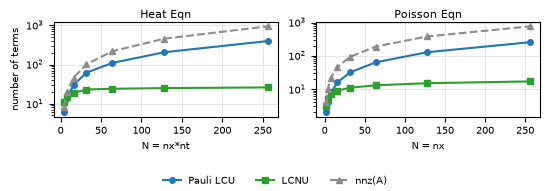

In [4]:
rows = report.pauli_vs_lcnu()
report.plot_pauli_vs_lcnu(rows)

## 5. The circuit for one term

Four of the five basis elements are not unitary. Unitary completion solves this with one ancilla.

| $\sigma$ | completion $\bar\sigma$ | complement $\sigma^c$ |
|---|---|---|
| $\sigma_+$ | $\sigma_x$ | $\sigma_-$ |
| $\sigma_-$ | $\sigma_x$ | $\sigma_+$ |
| $\sigma_+\sigma_-$ | $\mathbf{I}$ | $\sigma_-\sigma_+$ |
| $\sigma_-\sigma_+$ | $\mathbf{I}$ | $\sigma_+\sigma_-$ |
| $\mathbf{I}$ | $\mathbf{I}$ | $\mathbf{0}$ |

Set $\bar{\mathbf{A}}_l = \otimes_k \bar\sigma_k$ and $\mathbf{A}_l^c = \bar{\mathbf{A}}_l - \mathbf{A}_l$. Then this operator is unitary:

$$\mathbf{U}_l = \begin{pmatrix}\mathbf{A}_l & \mathbf{A}_l^c\\ \mathbf{A}_l^c & \mathbf{A}_l\end{pmatrix},
\qquad \mathbf{U}_l|0\rangle|\psi\rangle = |0\rangle\,\mathbf{A}_l|\psi\rangle + |1\rangle\,\mathbf{A}_l^c|\psi\rangle.$$

$\mathbf{A}_l^c$ has no tensor product form, so factor $\mathbf{U}_l = \mathbf{U}_{l,1}\mathbf{U}_{l,2}$:

$$\mathbf{U}_{l,1} = \begin{pmatrix}\mathbf{I}-\mathbf{D} & \mathbf{D}\\ \mathbf{D} & \mathbf{I}-\mathbf{D}\end{pmatrix},
\quad \mathbf{D} = \mathbf{A}_l\mathbf{A}_l^T, \qquad
\mathbf{U}_{l,2} = \sigma_x\otimes\bar{\mathbf{A}}_l.$$

$\mathbf{D}$ is diagonal with 0s and 1s, so $\mathbf{U}_{l,1}$ is one multi-controlled $X$ gate on the ancilla.

**Control polarity.** The control state at position $p$ is the row bit of that letter. 
1. `+` and `P` give an open control.
2.  `-` and `M` give a closed control. 
3. `I` gives no control. A term with $k$ identity letters needs only a $C^{n-k}X$ gate.

In [5]:
term = "-IP"
print("A_l =", pretty(term))
print(explain_term(term))
print()
print(sigma_term_circuit(term).draw(output="text", fold=90))

A_l = s- x I x s+s-
Abar_l = sx x I x I
k = number of identity factors = 1
so U_{l,1} needs a C^2X gate

letter -> wire:
   position 0  s-    -> q2
   position 1  I     -> q1
   position 2  s+s-  -> q0

               
q_0: ───────o──
            │  
q_1: ───────┼──
     ┌───┐  │  
q_2: ┤ X ├──■──
     ├───┤┌─┴─┐
 a1: ┤ X ├┤ X ├
     └───┘└───┘


A Sigma term costs at most $n+1$ single-qubit gates and one $C^mX$. A Pauli term costs single-qubit gates only. The Sigma basis pays slightly more per term and saves on the term count.

## 6. Hadamard tests

A variational algorithm never sees $\mathbf{A}$. It needs two kinds of number:

$$\langle\psi_1|\mathbf{A}_l|\psi_2\rangle, \qquad
\langle\psi_1|\mathbf{A}_i^\dagger\mathbf{M}\mathbf{A}_j|\psi_2\rangle,
\qquad |\psi_1\rangle = \mathbf{U}|0\rangle, \quad |\psi_2\rangle = \mathbf{V}|0\rangle.$$

The plain Hadamard test needs a unitary in the middle, and $\mathbf{A}_l$ is not unitary. Use $\mathbf{U}_l$ instead, then discard the branch where the completion ancilla reads 1.

### 6.1 One operator

Use two ancillas. `a0` interferes and `a1` completes. Take these steps:

1. Apply $H$ to `a0`. For the imaginary part, apply $S^\dagger$ next.
2. Apply $\mathbf{U}$ to the system, controlled on `a0` = 0.
3. Apply $\mathbf{V}$ to the system, controlled on `a0` = 1.
4. Apply $\mathbf{U}_l$ to (`a1`, system), controlled on `a0` = 1.
5. Apply $H$ to `a0`, then measure both ancillas.

The state before step 5 is

$$\tfrac{1}{\sqrt2}\big(|00\rangle|\psi_1\rangle + |10\rangle\,\mathbf{A}_l|\psi_2\rangle
+ |11\rangle\,\mathbf{A}_l^c|\psi_2\rangle\big),$$

and the two outcomes with `a1` = 0 give the answer:

$$P_{00} - P_{10} = \mathrm{Re}\,\langle\psi_1|\mathbf{A}_l|\psi_2\rangle.$$

Both ancillas sit above the system register, so `a1` is the most significant qubit of $\mathbf{U}_l$. Qiskit draws that qubit on the bottom wire. On hardware the error falls as $1/\sqrt{n_\text{shots}}$.

In [6]:
prep_U, prep_V = random_state_prep(3, 1, "U"), random_state_prep(3, 2, "V")
psi1, psi2 = state_of(prep_U), state_of(prep_V)
print(hadamard_test_single("-IP", prep_U, prep_V).draw(output="text", fold=95))

print("\n  A_l                  Hadamard test          exact                  error")
for w in ["-IP", "+M-", "I+-", "PPP", "III"]:
    got = inner_single(w, prep_U, prep_V)
    want = psi1.conj() @ (sigma_matrix(w) @ psi2)
    print("  %-20s %+.5f%+.5fj   %+.5f%+.5fj   %.1e"
          % (pretty(w), got.real, got.imag, want.real, want.imag, abs(got - want)))

          ┌────┐┌────┐┌─────────┐     
q_0: ─────┤0   ├┤0   ├┤0        ├─────
          │    ││    ││         │     
q_1: ─────┤1 U ├┤1 V ├┤1        ├─────
          │    ││    ││  U[-IP] │     
q_2: ─────┤2   ├┤2   ├┤2        ├─────
          └─┬──┘└─┬──┘│         │     
 a1: ───────┼─────┼───┤3        ├─────
     ┌───┐  │     │   └────┬────┘┌───┐
 a0: ┤ H ├──o─────■────────■─────┤ H ├
     └───┘                       └───┘

  A_l                  Hadamard test          exact                  error
  s- x I x s+s-        -0.03125-0.03615j   -0.03125-0.03615j   8.3e-17
  s+ x s-s+ x s-       +0.07365-0.04542j   +0.07365-0.04542j   7.6e-17
  I x s+ x s-          -0.02969+0.11765j   -0.02969+0.11765j   1.2e-16
  s+s- x s+s- x s+s-   +0.01837+0.00309j   +0.01837+0.00309j   2.1e-17
  I x I x I            +0.58405+0.19041j   +0.58405+0.19041j   5.6e-16


### 6.2 Two operators

Write the second quantity as an overlap of two prepared vectors:

$$\langle\psi_1|\mathbf{A}_i^\dagger\mathbf{M}\mathbf{A}_j|\psi_2\rangle
= \big(\mathbf{A}_i|\psi_1\rangle\big)^\dagger\,\mathbf{M}\,\big(\mathbf{A}_j|\psi_2\rangle\big).$$

Put $\mathbf{U}_i$ on the `a0` = 0 branch and $\mathbf{U}_j$ on the `a0` = 1 branch. Both branches share the ancilla `a1`. Apply $\mathbf{M}$ on the `a0` = 1 branch only, because an uncontrolled $\mathbf{M}$ cancels through $\mathbf{M}^\dagger\mathbf{M} = \mathbf{I}$.

The readout rule does not change.

In [7]:
prep_M = QuantumCircuit(3, name="M")           # a cheap unitary to play the role of M
for p in range(3):
    prep_M.ry(0.4 * (p + 1), p)
for p in range(2):
    prep_M.cx(p, p + 1)
M = circuit_matrix(prep_M)

print(hadamard_test_pair("-IP", "+M-", prep_U, prep_V, prep_M).draw(output="text", fold=105))

print("\n  A_i    A_j    M    Hadamard test          exact                  error")
for wi, wj, pm, tag in [("-IP", "+M-", prep_M, "M"), ("I+-", "PPP", prep_M, "M"),
                        ("+I-", "-IM", None, "I")]:
    got = inner_pair(wi, wj, prep_U, prep_V, pm)
    Mm = np.eye(8) if pm is None else M
    want = psi1.conj() @ (sigma_matrix(wi).T.conj() @ Mm @ sigma_matrix(wj) @ psi2)
    print("  %-5s  %-5s  %s    %+.5f%+.5fj   %+.5f%+.5fj   %.1e"
          % (wi, wj, tag, got.real, got.imag, want.real, want.imag, abs(got - want)))

          ┌────┐┌────┐┌─────────┐┌────┐┌─────────┐     
q_0: ─────┤0   ├┤0   ├┤0        ├┤0   ├┤0        ├─────
          │    ││    ││         ││    ││         │     
q_1: ─────┤1 U ├┤1 V ├┤1        ├┤1 M ├┤1        ├─────
          │    ││    ││  U[+M-] ││    ││  U[-IP] │     
q_2: ─────┤2   ├┤2   ├┤2        ├┤2   ├┤2        ├─────
          └─┬──┘└─┬──┘│         │└─┬──┘│         │     
 a1: ───────┼─────┼───┤3        ├──┼───┤3        ├─────
     ┌───┐  │     │   └────┬────┘  │   └────┬────┘┌───┐
 a0: ┤ H ├──o─────■────────■───────■────────o─────┤ H ├
     └───┘                                        └───┘

  A_i    A_j    M    Hadamard test          exact                  error
  -IP    +M-    M    +0.00182-0.00132j   +0.00182-0.00132j   2.2e-17
  I+-    PPP    M    -0.00064+0.00033j   -0.00064+0.00033j   8.5e-18
  +I-    -IM    I    +0.00000+0.00000j   +0.00000+0.00000j   0.0e+00


## 7. The VQLS cost functions

VQLS minimizes a cost function over the ansatz parameters. Take $|b\rangle = \mathbf{U}|0\rangle$, $|\psi\rangle = \mathbf{V}(\theta)|0\rangle$ and $|\phi\rangle = \mathbf{A}|\psi\rangle$.

$$C_g = 1 - \frac{|\langle b|\phi\rangle|^2}{\langle\phi|\phi\rangle}, \qquad
\langle\phi|\phi\rangle = \sum_{i,j}\alpha_i\bar\alpha_j\,\beta_{ij}, \qquad
|\langle b|\phi\rangle|^2 = \sum_{i,j}\alpha_i\bar\alpha_j\,\gamma_{ij}.$$

$\gamma_{ij} = c_i\bar c_j$ with $c_i = \langle b|\mathbf{A}_i|\psi\rangle$, so $\gamma$ costs $n_l$ single-operator tests. $\beta_{ij} = \langle\psi|\mathbf{A}_j^\dagger\mathbf{A}_i|\psi\rangle$ costs $n_l(n_l+1)/2$ two-operator tests.

The local cost function resists barren plateaus, and it adds a factor of $n$:

$$C_l = 1 - \frac{1}{n\,\langle\phi|\phi\rangle}\sum_{k=1}^{n}\sum_{i,j}
\alpha_i\bar\alpha_j\,\frac{\beta_{ij}+\delta_{ijk}}{2}, \qquad
\delta_{ijk} = \langle\psi|\mathbf{A}_j^\dagger\,\mathbf{U}(Z_k\otimes\mathbf{I})\mathbf{U}^\dagger\,\mathbf{A}_i|\psi\rangle.$$

$\delta_{ijk}$ is the two-operator test with $\mathbf{M} = \mathbf{U}(Z_k\otimes\mathbf{I})\mathbf{U}^\dagger$. Build that $\mathbf{M}$ as a circuit. Prepare, apply $Z$, then unprepare.

Both cost functions must reach 0 at the exact solution. The next cell checks that.

In [8]:
n_q, layers = 4, 2
theta = np.random.default_rng(11).uniform(0, 2 * np.pi, n_params(n_q, layers))
prep_b = prep_from_vector(b, "U")
prep_psi = ansatz(theta, n_q, layers)
prep_star = prep_from_vector(np.linalg.solve(A, b), "Vstar")
print("n_l = %d,   ansatz parameters = %d,   |b> error = %.1e"
      % (len(terms), len(theta),
         np.abs(state_of(prep_b) - b / np.linalg.norm(b)).max()))

beta = beta_from_tests(terms, prep_psi)
print("beta error = %.1e,   beta Hermitian: %s"
      % (np.abs(beta - beta_exact(terms, prep_psi)).max(),
         np.allclose(beta, beta.conj().T)))

print("\n  ansatz            cost    from tests        exact        difference")
for name, pv in [("random", prep_psi), ("exact solution", prep_star)]:
    for tag, got, want in [
            ("C_g", cost_global_from_tests(terms, prep_b, pv),
             cost_global_exact(A, b, pv)),
            ("C_l", cost_local_from_tests(terms, prep_b, pv),
             cost_local_exact(A, prep_b, pv))]:
        print("  %-16s  %s   %+.8f   %+.8f    %.1e"
              % (name, tag, got, want, abs(got - want)))

n_l = 16,   ansatz parameters = 12,   |b> error = 3.0e-16


beta error = 6.5e-16,   beta Hermitian: True

  ansatz            cost    from tests        exact        difference


  random            C_g   +0.99338780   +0.99338780    1.1e-16
  random            C_l   +0.39784002   +0.39784002    5.6e-17


  exact solution    C_g   +0.00000000   +0.00000000    2.2e-16
  exact solution    C_l   -0.00000000   -0.00000000    6.6e-16


## 8. Automatic extraction

Every decomposition above came from a hand recursion. The reverse problem matters in practice.

**Given a sparse matrix, find a short LCNU decomposition with no prior knowledge of it.**

`src/autoextract.py` runs the same block split used to derive the heat matrix by hand, as an algorithm. Split on the most significant qubit:

$$\mathbf{B} = \begin{pmatrix}\mathbf{B}_{00} & \mathbf{B}_{01}\\ \mathbf{B}_{10} & \mathbf{B}_{11}\end{pmatrix}
= \sigma_+\sigma_-\otimes\mathbf{B}_{00} + \sigma_-\sigma_+\otimes\mathbf{B}_{11}
+ \sigma_+\otimes\mathbf{B}_{01} + \sigma_-\otimes\mathbf{B}_{10}$$

A zero block drops out, and each level halves the matrix, so the depth is $\log_2$ of the size.

### 8.1 Sharing the diagonal blocks

The two diagonal blocks overlap. Carry the shared part on one branch instead of two. Because $\sigma_+\sigma_- + \sigma_-\sigma_+ = \mathbf{I}$, any common part $\mathbf{C}$ gives an exact identity:

$$\sigma_+\sigma_-\otimes\mathbf{B}_{00} + \sigma_-\sigma_+\otimes\mathbf{B}_{11}
= \mathbf{I}\otimes\mathbf{C}
+ \sigma_+\sigma_-\otimes(\mathbf{B}_{00}-\mathbf{C})
+ \sigma_-\sigma_+\otimes(\mathbf{B}_{11}-\mathbf{C})$$

A large $\mathbf{C}$ leaves sparse residuals, and sparse residuals give few terms. The hand derivation $\mathbf{A}' = -\mathbf{T} + (\sigma_+\sigma_-)^{\otimes s} + (\sigma_-\sigma_+)^{\otimes s}$ is the choice $\mathbf{C} = \mathbf{B}_{00}$, whose residual holds only the two corners.

Three candidates get tried at every level:

| candidate | $\mathbf{C}$ |
|---|---|
| `b00` | $\mathbf{B}_{00}$, so the $\sigma_+\sigma_-$ branch vanishes |
| `b11` | $\mathbf{B}_{11}$, so the $\sigma_-\sigma_+$ branch vanishes |
| `minmag` | the smaller magnitude, entrywise |

`b00` and `b11` choose one block for the whole level. `minmag` makes the same choice per entry, so one residual is exactly zero at every entry and no entry position goes down both branches. Magnitude is the rule because a zero has the smallest magnitude: where one block holds an entry and the other holds a zero, `minmag` keeps the zero.

No single candidate is best on its own. On the heat matrix at $n_x=n_t=32$, `b00` alone gives 1277 terms, `b11` alone 87 and `minmag` alone 101. All three together give 33. A memo keyed on block content collapses the repeated subproblems, so the search stays cheap on a structured matrix.


family   size            N     nnz   recursive  hand-compute    error
------------------------------------------------------------------------
Poisson  nx=8            8      22           7             7    0e+00
Poisson  nx=16          16      46           9             9    0e+00
Poisson  nx=32          32      94          11            11    0e+00
Poisson  nx=64          64     190          13            13    0e+00
Poisson  nx=128        128     382          15            15    0e+00
Poisson  nx=256        256     766          17            17    0e+00
------------------------------------------------------------------------
heat     nx=nt=4        16      46          16            16    0e+00
heat     nx=nt=8        64     218          23            21    2e-16
heat     nx=nt=16      256     946          28            26    0e+00
heat     nx=nt=32     1024    3938          33            31    0e+00
------------------------------------------------------------------------
wave     nx

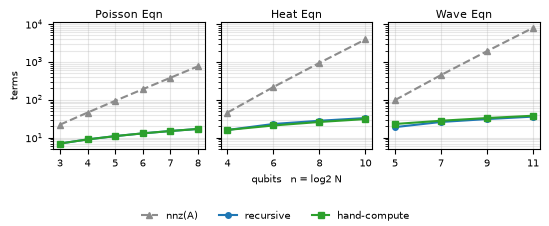

gap to hand-compute, and the increment per doubling of n_x

  family    size        recursive  hand   gap   d(rec)  d(hand)
  Poisson   nx=8              7      7     0       -       -
  Poisson   nx=16             9      9     0       2       2
  Poisson   nx=32            11     11     0       2       2
  Poisson   nx=64            13     13     0       2       2
  Poisson   nx=128           15     15     0       2       2
  Poisson   nx=256           17     17     0       2       2
  heat      nx=nt=4          16     16     0       -       -
  heat      nx=nt=8          23     21     2       7       5
  heat      nx=nt=16         28     26     2       5       5
  heat      nx=nt=32         33     31     2       5       5
  wave      nx=nt=4          19     23    -4       -       -
  wave      nx=nt=8          26     28    -2       7       5
  wave      nx=nt=16         31     33    -2       5       5
  wave      nx=nt=32         36     38    -2       5       5

The increments conver

In [9]:
data = report.autoextract_sweep()
report.plot_autoextract(data)